In [107]:
%matplotlib inline

In [101]:
from tensorflow import argmax
from matplotlib import pyplot
from PIL import Image

AttributeError: 'ZMQInteractiveShell' object has no attribute 'magic'

In [6]:
from tensorflow.keras.models import load_model
from keras import models, layers
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

In [7]:
fashionCNNModel = load_model("../Models/fashionCNNModel.h5")

In [3]:
fashionCNNModel.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [37]:
y_predict = fashionCNNModel.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


actual:  7
predicted:  5

actual:  2
predicted:  6

actual:  4
predicted:  6

actual:  9
predicted:  5

actual:  6
predicted:  4

actual:  0
predicted:  6

actual:  6
predicted:  0

actual:  3
predicted:  6

actual:  2
predicted:  6

actual:  4
predicted:  6



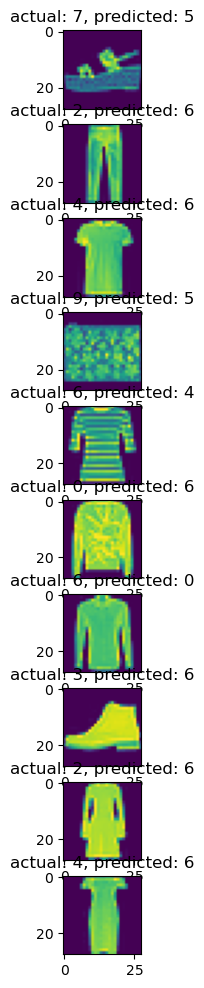

In [126]:
i=0
wrongPredictions = 0
y_predict_forMatrix = []

img, axes = plt.subplots(10, 1, figsize=(12,12))

while i<len(y_predict):
    y_predict_forMatrix.append(int(argmax(y_predict[i])))
    if int(argmax(y_predict[i]))  != y_test[i] and wrongPredictions <10:
        
        print("actual: ",y_test[i])
        print("predicted: ", int(argmax(y_predict[i])))
        axes[wrongPredictions].imshow(X_train[i])
        axes[wrongPredictions].set_title(f"actual: {y_test[i]}, predicted: {int(argmax(y_predict[i]))}")
        wrongPredictions+=1
        print()
    i+=1
plt.show()

In [95]:
fashionCNNModel_confusionMatrix = confusion_matrix(y_predict_forMatrix, y_test)

In [96]:
print(fashionCNNModel_confusionMatrix)

[[741   2  17  15   1   0  75   0   3   0]
 [  9 994   2  74   2   0   6   0   2   0]
 [ 32   1 763  24  28   0  46   0   1   1]
 [ 13   2   5 763  10   0  19   0   0   0]
 [ 15   1 122  76 906   0 105   0   1   0]
 [  1   0   0   0   0 994   0 174   1  25]
 [182   0  88  46  50   0 730   0   3   0]
 [  0   0   0   0   0   1   0 778   0  10]
 [  7   0   3   2   3   1  19   0 989   1]
 [  0   0   0   0   0   4   0  48   0 963]]


In [ ]:
"""
It seems that the model is more likely to falsely predict the label 6 more than any other label.

One way to improve the CNN preformance could be to slightly increase the resolution of the images.
"""